✅ Model Loaded Successfully.
🔮 Generating Predictions...
📊 Final Plot saved to: c:\Users\Yahya\Desktop\My folder\WQU\10. Capstone\Thesis Work\Machine Learning & Deep Learning in Finance\NLP for Intraday Volatility Prediction\images\final_prediction_comparison.png

--- 🏆 Final Model Metrics ---
RMSE (Root Mean Squared Error): 0.000206
MAE  (Mean Absolute Error):     0.000151


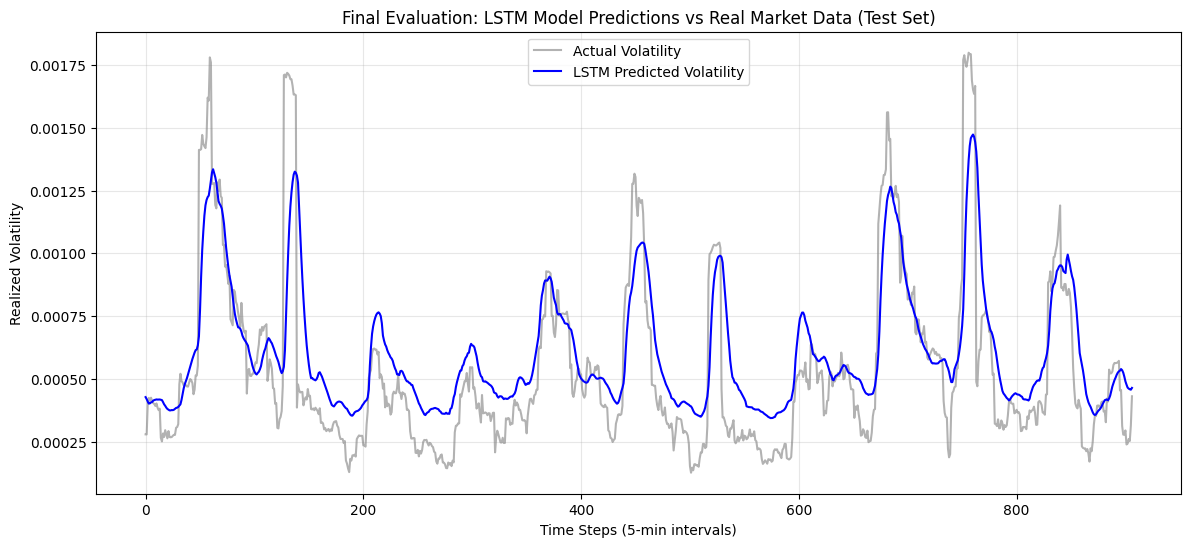

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path

# ==========================================
# 1. SETUP
# ==========================================
REQUIRED_FOLDERS = ['data', 'code', 'models', 'images', 'output']
def get_project_root():
    current_path = Path.cwd()
    if current_path.name in REQUIRED_FOLDERS: return current_path.parent
    return current_path

BASE_PATH = get_project_root()
DATA_PATH = BASE_PATH / 'data'
MODEL_PATH = BASE_PATH / 'models'
IMAGE_PATH = BASE_PATH / 'images'

# Load Data Again (to ensure clean slate)
df = pd.read_csv(DATA_PATH / 'final_dataset_ready.csv')
df.dropna(subset=['target_volatility'], inplace=True)

# Features
feature_cols = ['log_return', 'rolling_volatility', 'volume', 'sentiment_pos', 'sentiment_neg']
target_col = 'target_volatility'

# Re-Initialize Scalers (Must match training scaling exactly)
scaler_features = MinMaxScaler()
scaler_target = MinMaxScaler()

X_raw = scaler_features.fit_transform(df[feature_cols])
y_raw = scaler_target.fit_transform(df[[target_col]])

# Re-Split
train_size = int(len(df) * 0.8)
X_test_raw = X_raw[train_size:]
y_test_raw = y_raw[train_size:]

# Sliding Window Function
WINDOW_SIZE = 12
def create_sequences(X, y, time_steps=12):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

X_test, y_test = create_sequences(X_test_raw, y_test_raw, WINDOW_SIZE)
X_test_t = torch.FloatTensor(X_test)

# ==========================================
# 2. LOAD TRAINED MODEL
# ==========================================
# We must redefine the class to load the weights
class VolatilityLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(VolatilityLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        h0 = torch.zeros(2, x.size(0), 64).to(x.device) # num_layers=2, hidden=64
        c0 = torch.zeros(2, x.size(0), 64).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

model = VolatilityLSTM(input_size=5, hidden_size=64, num_layers=2, output_size=1)
model.load_state_dict(torch.load(MODEL_PATH / 'lstm_volatility_model.pth'))
model.eval()
print("Model Loaded Successfully.")

# ==========================================
# 3. GENERATE PREDICTIONS
# ==========================================
print("Generating Predictions...")
with torch.no_grad():
    y_pred_scaled = model(X_test_t).numpy()

# Inverse Transform to get actual Volatility values (not 0-1 scaled)
y_pred = scaler_target.inverse_transform(y_pred_scaled)
y_actual = scaler_target.inverse_transform(y_test)

# ==========================================
# 4. VISUALIZATION
# ==========================================
plt.figure(figsize=(14, 6))
plt.plot(y_actual, label='Actual Volatility', color='gray', alpha=0.6)
plt.plot(y_pred, label='LSTM Predicted Volatility', color='blue', linewidth=1.5)

plt.title('Final Evaluation: LSTM Model Predictions vs Real Market Data (Test Set)')
plt.xlabel('Time Steps (5-min intervals)')
plt.ylabel('Realized Volatility')
plt.legend()
plt.grid(True, alpha=0.3)

# Save
save_path = IMAGE_PATH / 'final_prediction_comparison.png'
plt.savefig(save_path)
print(f"Final Plot saved to: {save_path}")

# Calculate Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mae = mean_absolute_error(y_actual, y_pred)

print("\n--- Final Model Metrics ---")
print(f"RMSE (Root Mean Squared Error): {rmse:.6f}")
print(f"MAE  (Mean Absolute Error):     {mae:.6f}")